In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [287]:
df=pd.read_csv("loan_Data.csv")

In [288]:
df.shape

(614, 13)

In [289]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [290]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [291]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [292]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [293]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [294]:
df.drop_duplicates(inplace=True)

In [295]:
df.shape

(614, 13)

In [296]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [297]:

cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())



print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [298]:
#remove unwanted column
df.drop("Loan_ID",axis=1,inplace=True)

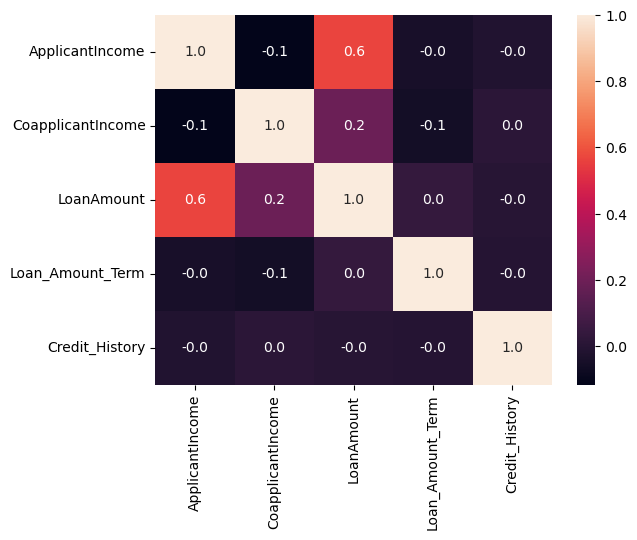

In [299]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".1f")
plt.show()

In [300]:
df['Gender'].value_counts()

Gender
Male      502
Female    112
Name: count, dtype: int64

In [301]:
df["Gender"]=df['Gender'].map({"Male":1,"Female":0}) 

df.rename(columns={"Gender":"is_male"},inplace=True)

In [302]:
df['is_male'].value_counts()

is_male
1    502
0    112
Name: count, dtype: int64

In [303]:
print(df['Self_Employed'].value_counts())
print(df['Married'].value_counts())

Self_Employed
No     532
Yes     82
Name: count, dtype: int64
Married
Yes    401
No     213
Name: count, dtype: int64


In [304]:
df["Married"]=df['Married'].map({"Yes":1,"No":0}) 
df["Self_Employed"]=df['Self_Employed'].map({"Yes":1,"No":0}) 

df.rename(columns={"Married":"is_married"},inplace=True)
df.rename(columns={"Self_Employed":"is_self_employed"},inplace=True)


In [305]:
print(df['is_self_employed'].value_counts())
print(df['is_married'].value_counts())

is_self_employed
0    532
1     82
Name: count, dtype: int64
is_married
1    401
0    213
Name: count, dtype: int64


In [306]:
df.dtypes

is_male                int64
is_married             int64
Dependents            object
Education             object
is_self_employed       int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [307]:
df['Dependents']=df['Dependents'].replace("3+","3")

In [308]:
df['Dependents']=df['Dependents'].astype(int)

In [309]:
df.dtypes

is_male                int64
is_married             int64
Dependents             int64
Education             object
is_self_employed       int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [310]:
df['Education'].value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [311]:
df['Education']=df['Education'].map({"Graduate":1,"Not Graduate":0})

df.rename(columns={"Education":"is_graduate"},inplace=True)

In [312]:
df['is_graduate'].value_counts()

is_graduate
1    480
0    134
Name: count, dtype: int64

In [313]:
df.dtypes

is_male                int64
is_married             int64
Dependents             int64
is_graduate            int64
is_self_employed       int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [314]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [315]:
df['Loan_Status']=df['Loan_Status'].map({"Y":1,"N":0})

df.rename(columns={"Loan_Status":"is_loan_approved"},inplace=True)

In [316]:
df['is_loan_approved'].value_counts()

is_loan_approved
1    422
0    192
Name: count, dtype: int64

In [317]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [318]:
df=pd.get_dummies(df,columns=["Property_Area"])

In [319]:
df.columns

Index(['is_male', 'is_married', 'Dependents', 'is_graduate',
       'is_self_employed', 'ApplicantIncome', 'CoapplicantIncome',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'is_loan_approved',
       'Property_Area_Rural', 'Property_Area_Semiurban',
       'Property_Area_Urban'],
      dtype='object')

In [320]:
c=["Property_Area_Rural","Property_Area_Semiurban","Property_Area_Urban"]
for i in c:
    df[i] = df[i].astype(int)

In [321]:
df.dtypes

is_male                      int64
is_married                   int64
Dependents                   int64
is_graduate                  int64
is_self_employed             int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
is_loan_approved             int64
Property_Area_Rural          int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
dtype: object

In [322]:
df.isnull().sum()

is_male                    0
is_married                 0
Dependents                 0
is_graduate                0
is_self_employed           0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
is_loan_approved           0
Property_Area_Rural        0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

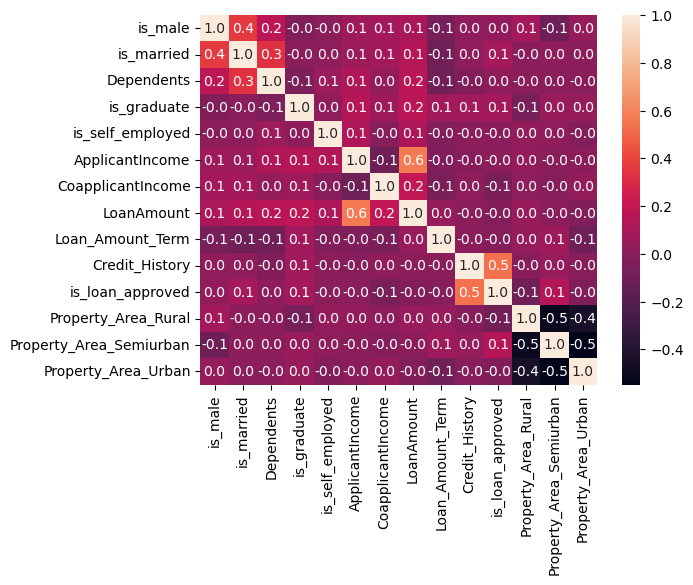

In [323]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".1f")
plt.show()

In [324]:
#now split the data.......

X=df.drop("is_loan_approved",axis=1)
y=df["is_loan_approved"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [325]:
X_train.shape

(491, 13)

In [326]:
X_test.shape

(123, 13)

In [327]:
from sklearn.tree import DecisionTreeClassifier

m1=DecisionTreeClassifier(max_depth=5,random_state=42)

m1.fit(X_train,y_train)

y_p1=m1.predict(X_test)

print(classification_report(y_test,y_p1))
print()
print()
print("-----------------------------------")
print("Accuracy Score of Decision Tree Classifier Model is :-",accuracy_score(y_test,y_p1))

              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



-----------------------------------
Accuracy Score of Decision Tree Classifier Model is :- 0.7560975609756098


In [328]:
from sklearn.ensemble import RandomForestClassifier

m2=RandomForestClassifier(n_estimators=100,class_weight="balanced",random_state=42)

m2.fit(X_train,y_train)

y_p2=m2.predict(X_test)

print(classification_report(y_test,y_p2))
print()
print()
print("-----------------------------------")
print("Accuracy Score of  Random Forest Classifier Model is :-",accuracy_score(y_test,y_p2))

              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75      0.93      0.83        80

    accuracy                           0.75       123
   macro avg       0.75      0.67      0.68       123
weighted avg       0.75      0.75      0.73       123



-----------------------------------
Accuracy Score of  Random Forest Classifier Model is :- 0.7479674796747967


In [332]:
col3=["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]

sc=StandardScaler()

X_scaled=X.copy()

X_scaled[col3]=sc.fit_transform(X_scaled[col3])

In [334]:
X_scaled

,is_male,is_married,Dependents,is_graduate,is_self_employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,0.072991,-0.554487,-0.211241,0.273231,1.0,0,0,1
1,1,1,1,1,0,-0.134412,-0.038732,-0.211241,0.273231,1.0,1,0,0
2,1,1,0,1,1,-0.393747,-0.554487,-0.948996,0.273231,1.0,0,0,1
3,1,1,0,0,0,-0.462062,0.251980,-0.306435,0.273231,1.0,0,0,1
4,1,0,0,1,0,0.097728,-0.554487,-0.056551,0.273231,1.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,1,0,-0.410130,-0.554487,-0.889500,0.273231,1.0,1,0,0
610,1,1,3,1,0,-0.212557,-0.554487,-1.258378,-2.522836,1.0,1,0,0
611,1,1,1,1,0,0.437174,-0.472404,1.276168,0.273231,1.0,0,0,1
612,1,1,2,1,0,0.357064,-0.554487,0.490816,0.273231,1.0,0,0,1


In [335]:
X_train_s,x_test_s,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [339]:
from sklearn.linear_model import LogisticRegression

m3=LogisticRegression(max_iter=1000,class_weight="balanced")

m3.fit(X_train_s,y_train)

y_p3=m3.predict(x_test_s)

print(classification_report(y_test,y_p3))
print()
print()
print("-----------------------------------")
print("Accuracy Score of  Logistoc Regression Classifier Model is :-",accuracy_score(y_test,y_p3))

              precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123



-----------------------------------
Accuracy Score of  Logistoc Regression Classifier Model is :- 0.7804878048780488
